In [1]:
from utils import ExpChecker

checker = ExpChecker("alphabattle")
checker.suggest_commands(device="cuda:4", grid="final")
checker.summary_notebook(hide_finished=True)


No commands to suggest. Everything looks complete for the standard scope.


overall,experiment,checks,lock(meta.final)
MISS,seqvae,lr:DONE (6/6) ; final:MISS,lock:—


In [1]:
from utils import ExpNavigator, Exp

nav = ExpNavigator("/home/transaction-generation/log/gen-paper/age")
nav.run()

Output()

In [4]:
from utils import FinalTables
import os
import shutil

datasets = ["age", "gender", "alphabattle"]

results_dir = "/home/transaction-generation/log/results"
os.makedirs(results_dir, exist_ok=True)

for dataset in datasets:
    print(f"Processing dataset: {dataset}")
    ft = FinalTables(f"/home/transaction-generation/log/gen-paper/{dataset}")
    for horizon in ["4", "16", "32", "64"]:
        print(f"  Horizon: {horizon}")
        df = ft.all_horizon_tables()[f"horizon_{horizon}"]
        data_cols = df.columns[1:]
        
        # df = df[["ldm/vae", "ldm/vae/booster/wasserstein_barybooster", "detpp"]]
        # data_cols = df.columns

        styled = df.round(3).style
        styled = styled.background_gradient(
            subset=data_cols,
            axis=1,
            cmap="YlGn",
            vmin=0, 
            vmax=df[data_cols].quantile(1).max()
        )
        display(styled)
        # Save each dataframe to results folder
        outfile = os.path.join(results_dir, f"{dataset}_horizon_{horizon}.csv")
        df.to_csv(outfile)
        print(f"    Saved: {outfile}")

# Zip all results at the end
zipfile_path = os.path.join(results_dir, "results.zip")
shutil.make_archive(base_name=zipfile_path.replace(".zip", ""), format='zip', root_dir=results_dir)
print(f"All results have been zipped to: {zipfile_path}")

Processing dataset: age
  Horizon: 4


,baselines/gt,baselines/hist_sampler,baselines/mode,baselines/repeat,ldm/vae,ldm/vae/booster/wasserstein_barybooster1,cdiff/booster/wasserstein_barybooster1,cdiff,ar,multitoken,detpp
test_GenOTD,1.000000,0.123000,0.290000,0.199000,0.177000,0.391000,0.313000,0.219000,0.341000,0.345000,0.391000
test_Matched R1 amount_rur,1.000000,-0.301000,0.000000,-0.220000,-0.248000,0.157000,0.105000,-0.107000,0.045000,0.022000,0.141000
test_Matched trans_date,1.000000,-0.359000,0.000000,-0.159000,-0.207000,0.163000,-0.061000,-0.121000,0.039000,0.123000,0.153000
test_Matched F1 small_group,1.000000,0.237000,0.160000,0.268000,0.252000,0.340000,0.280000,0.170000,0.312000,0.274000,0.344000
test_GenOTD log1p[amount_rur],1.000000,0.206000,0.290000,0.273000,0.245000,0.415000,0.331000,0.236000,0.350000,0.348000,0.415000
test_Cardinality on small_group gen,3.212000,3.045000,1.000000,3.162000,3.170000,2.582000,3.260000,3.552000,2.533000,2.176000,2.574000
test_Density shape,0.997000,0.979000,0.785000,0.981000,0.984000,0.897000,0.876000,0.892000,0.860000,0.839000,0.867000
test_Density trend,1.000000,0.921000,0.407000,0.895000,0.876000,0.634000,0.512000,0.746000,0.516000,0.405000,0.499000
test_Detection score (4 hist) mean,1.012000,0.716000,0.001000,0.008000,1.003000,0.311000,0.258000,0.438000,0.020000,0.002000,0.020000


    Saved: /home/transaction-generation/log/results/age_horizon_4.csv
  Horizon: 16


,baselines/gt,baselines/hist_sampler,baselines/mode,baselines/repeat,ldm/vae,ldm/vae/booster/wasserstein_barybooster1,cdiff/booster/wasserstein_barybooster1,ldm/vae_h4,cdiff,cdiff_h4,ar,multitoken,multitoken_h4,detpp,detpp_h4
test_GenOTD,1.000000,0.235000,0.269000,0.323000,0.293000,0.446000,0.408000,0.255000,0.348000,0.275000,0.338000,0.344000,0.350000,0.440000,0.355000
test_Matched R1 amount_rur,1.000000,0.098000,0.000000,0.127000,0.090000,0.354000,0.295000,0.041000,0.178000,0.103000,0.077000,0.021000,0.034000,0.296000,0.197000
test_Matched trans_date,1.000000,-0.289000,0.000000,0.018000,-0.046000,0.257000,0.172000,-0.139000,0.120000,-0.088000,0.094000,0.128000,0.154000,0.278000,0.027000
test_Matched F1 small_group,1.000000,0.303000,0.074000,0.339000,0.306000,0.364000,0.358000,0.289000,0.278000,0.199000,0.259000,0.280000,0.260000,0.350000,0.259000
test_GenOTD log1p[amount_rur],1.000000,0.304000,0.269000,0.394000,0.365000,0.481000,0.440000,0.333000,0.384000,0.310000,0.348000,0.347000,0.355000,0.471000,0.390000
test_Cardinality on small_group gen,7.456000,7.292000,1.000000,7.354000,7.253000,5.039000,5.501000,7.280000,7.827000,10.263000,8.927000,4.528000,3.574000,4.836000,2.918000
test_Density shape,0.997000,0.986000,0.791000,0.991000,0.987000,0.936000,0.926000,0.979000,0.972000,0.878000,0.905000,0.857000,0.845000,0.893000,0.880000
test_Density trend,0.982000,0.900000,0.427000,0.894000,0.926000,0.761000,0.663000,0.957000,0.865000,0.763000,0.601000,0.420000,0.394000,0.562000,0.559000
test_Detection score (16 hist) mean,1.056000,0.398000,0.000000,0.011000,1.002000,0.227000,0.156000,0.880000,0.377000,0.096000,0.000000,0.000000,0.000000,0.000000,0.001000


    Saved: /home/transaction-generation/log/results/age_horizon_16.csv
  Horizon: 32


...

    Saved: /home/transaction-generation/log/results/alphabattle_horizon_16.csv
  Horizon: 32


,baselines/gt,baselines/hist_sampler,baselines/mode,baselines/repeat,ldm/vae,ldm/vae/booster/wasserstein_barybooster1,cdiff/booster/wasserstein_barybooster1,ldm/vae_h4,ldm/vae_h16,cdiff,cdiff_h4,cdiff_h16,ar,multitoken,multitoken_h4,multitoken_h16,detpp,detpp_h4,detpp_h16
test_GenOTD,1.000000,0.382000,0.203000,0.440000,0.405000,0.495000,0.274000,0.352000,0.382000,0.251000,0.163000,0.182000,0.286000,0.286000,0.269000,0.292000,0.424000,0.319000,0.425000
test_Matched R1 amnt,1.000000,0.498000,-0.000000,0.524000,0.479000,0.583000,0.086000,0.398000,0.453000,-0.015000,-0.505000,-0.373000,0.043000,-0.000000,0.019000,0.021000,0.364000,0.245000,0.288000
test_Matched hours_since_first_tx,1.000000,-0.049000,0.000000,0.147000,0.148000,0.337000,0.006000,-0.022000,0.096000,0.125000,0.128000,0.161000,0.064000,-0.042000,0.078000,0.003000,0.294000,0.137000,0.325000
test_Matched F1 mcc_category,1.000000,0.424000,0.081000,0.444000,0.400000,0.459000,0.285000,0.376000,0.388000,0.275000,0.226000,0.247000,0.287000,0.369000,0.229000,0.346000,0.440000,0.253000,0.424000
test_Cardinality on mcc_category gen,7.473000,7.576000,1.000000,7.499000,7.340000,6.132000,5.914000,6.678000,7.211000,7.223000,4.530000,5.294000,3.844000,5.337000,2.837000,4.806000,5.909000,2.615000,5.028000
test_Density shape,1.000000,0.984000,0.801000,0.991000,0.977000,0.943000,0.733000,0.966000,0.980000,0.740000,0.705000,0.712000,0.840000,0.855000,0.804000,0.845000,0.884000,0.850000,0.902000
test_Density trend,0.961000,0.949000,0.567000,0.955000,0.914000,0.868000,0.578000,0.907000,0.935000,0.602000,0.540000,0.554000,0.620000,0.712000,0.666000,0.685000,0.563000,0.660000,0.778000
test_Detection score (32 hist) mean,1.004000,0.544000,0.000000,0.009000,0.856000,0.177000,0.001000,0.601000,0.818000,0.004000,0.001000,0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


    Saved: /home/transaction-generation/log/results/alphabattle_horizon_32.csv
  Horizon: 64


,baselines/gt,baselines/hist_sampler,baselines/mode,baselines/repeat,ldm/vae,ldm/vae/booster/wasserstein_barybooster1,ldm/vae_h4,ldm/vae_h16,ldm/vae_h32,cdiff,cdiff_h4,cdiff_h16,cdiff_h32,ar,multitoken,multitoken_h4,multitoken_h16,multitoken_h32,detpp,detpp_h4,detpp_h16,detpp_h32
test_GenOTD,1.000000,0.424000,0.182000,0.486000,0.455000,0.522000,0.363000,0.402000,0.426000,0.281000,0.140000,0.169000,0.262000,0.258000,0.277000,0.233000,0.275000,0.275000,0.430000,0.285000,0.409000,0.423000
test_Matched R1 amnt,1.000000,0.593000,0.000000,0.620000,0.572000,0.642000,0.445000,0.532000,0.550000,0.118000,-0.595000,-0.479000,-0.019000,0.055000,-0.004000,0.001000,0.030000,0.026000,0.381000,0.254000,0.304000,0.379000
test_Matched hours_since_first_tx,1.000000,0.042000,0.000000,0.261000,0.305000,0.432000,0.024000,0.178000,0.234000,0.228000,0.182000,0.240000,0.202000,-0.085000,-0.020000,0.076000,-0.008000,-0.043000,0.351000,0.129000,0.388000,0.403000
test_Matched F1 mcc_category,1.000000,0.465000,0.062000,0.487000,0.439000,0.480000,0.396000,0.414000,0.422000,0.286000,0.205000,0.240000,0.283000,0.395000,0.369000,0.175000,0.327000,0.356000,0.450000,0.200000,0.376000,0.413000
test_Cardinality on mcc_category gen,9.544000,9.372000,1.000000,9.556000,9.248000,7.778000,8.444000,9.223000,9.143000,9.485000,5.436000,6.421000,8.897000,9.861000,6.458000,3.042000,5.641000,6.248000,6.898000,2.628000,5.074000,5.989000
test_Density shape,1.000000,0.982000,0.796000,0.991000,0.972000,0.952000,0.956000,0.974000,0.974000,0.757000,0.684000,0.696000,0.724000,0.878000,0.850000,0.796000,0.834000,0.840000,0.890000,0.852000,0.900000,0.880000
test_Density trend,0.959000,0.900000,0.632000,0.948000,0.916000,0.878000,0.899000,0.923000,0.916000,0.607000,0.500000,0.538000,0.582000,0.540000,0.722000,0.655000,0.693000,0.585000,0.786000,0.592000,0.778000,0.568000
test_Detection score (64 hist) mean,1.008000,0.307000,0.000000,0.072000,0.780000,0.176000,0.401000,0.703000,0.832000,0.003000,0.000000,0.000000,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


    Saved: /home/transaction-generation/log/results/alphabattle_horizon_64.csv
All results have been zipped to: /home/transaction-generation/log/results/results.zip


In [ ]:
from utils import ExpNavigator, Exp

nav = ExpNavigator("/home/transaction-generation/log/gen-paper/age/")
nav.run()

In [25]:
from glob import glob
import pandas as pd
from pathlib import Path
res = pd.DataFrame()

for path in glob("/home/transaction-generation/log/gen-paper/age/boosters/**/results.csv"):
    path = Path(path)
    df = pd.read_csv(path, index_col=0)
    ldm = "EMA_GenOTD" in df.index
    for i in df.index:
        if "test" in i:
            if ldm:
                continue
        elif "EMA" not in i:
            continue
        if any(m in i for m in ["Visualization", "Paired", "std", "loss"]):
            continue
        res.loc[i.replace("EMA", "test"), path.parent.name] = df.loc[i, "mean"]
res[['ldm_vae_default', 'ldm_vae_barybooster', 'ldm_vae_wasserstein_barybooster', 'detpp_default']]

,ldm_vae_default,ldm_vae_barybooster,ldm_vae_wasserstein_barybooster,detpp_default
test_GenOTD,0.353716,0.443809,0.467593,0.466640
test_Matched R1 amount_rur,0.176256,0.345772,0.365830,0.327014
test_Matched trans_date,0.101395,0.281798,0.309570,0.345671
test_Matched F1 small_group,0.335429,0.348754,0.370171,0.346311
test_GenOTD log1p[amount_rur],0.437273,0.488157,0.513019,0.498767
test_Cardinality on small_group gen,9.638020,8.602135,7.092197,6.285977
test_Density shape,0.983627,0.972319,0.953526,0.892318
test_Density trend,0.913240,0.932413,0.899747,0.601740
test_Detection score (32 hist) mean,0.930540,0.654519,0.180772,0.000142


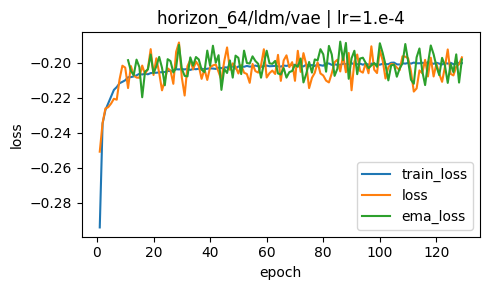

In [ ]:
from utils import Exp

e = Exp("/home/transaction-generation/log/gen-paper/age/horizon_64/ldm/vae")
e.plot_losses("1.e-4")

Loss metrics found: ['EMA_loss', 'loss', 'test_loss']


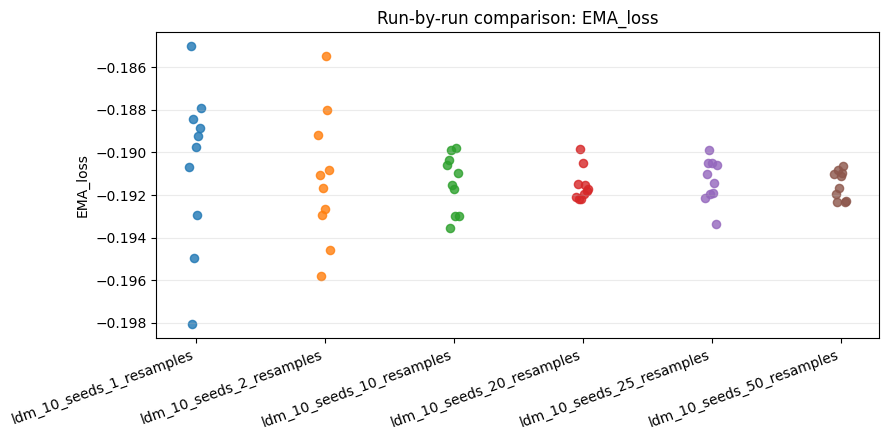

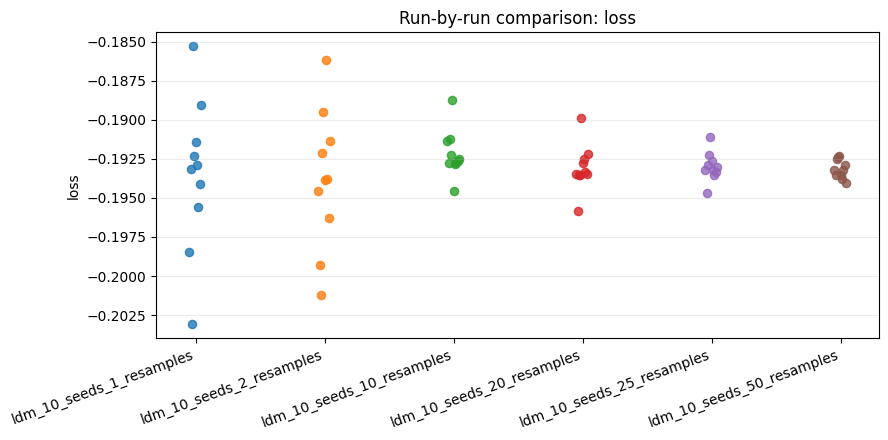

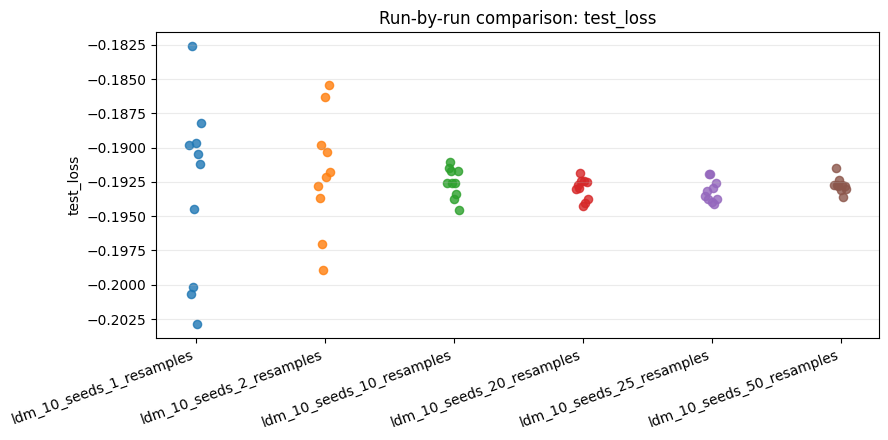

In [23]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

base = Path("/home/transaction-generation/log/gen-paper/age/reeval/")

csv_paths = sorted(
    base.glob("ldm_*_seeds_*_resamples/results.csv"),
    key=lambda p: int(re.search(r"seeds_(\d+)_resamples", p.parent.name).group(1))
)

# load all experiments
exp_tables = {}
for p in csv_paths:
    exp_name = p.parent.name
    df = pd.read_csv(p, index_col=0)
    exp_tables[exp_name] = df

# detect run columns (usually "0", "1", ..., "9")
sample_cols = [c for c in next(iter(exp_tables.values())).columns if str(c).isdigit()]

# choose only loss-like metrics
loss_metrics = sorted(
    {idx for df in exp_tables.values() for idx in df.index if "loss" in idx.lower()}
)
print("Loss metrics found:", loss_metrics)

# one chart per loss metric, showing each seed/run value for each experiment
for metric in loss_metrics:
    plt.figure(figsize=(9, 4.5))

    exp_names = list(exp_tables.keys())
    for i, exp in enumerate(exp_names):
        df = exp_tables[exp]
        if metric not in df.index:
            continue
        vals = df.loc[metric, sample_cols].astype(float).values

        # jitter x a little so individual runs are visible
        x = [i] * len(vals)
        jitter = pd.Series(range(len(vals))).map(lambda k: (k - len(vals)/2) * 0.01).values
        x = [xx + jj for xx, jj in zip(x, jitter)]

        plt.scatter(x, vals, alpha=0.8, s=35, label=exp if i == 0 else None)

    plt.xticks(range(len(exp_names)), exp_names, rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"Run-by-run comparison: {metric}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()